In [1]:
import sys
import pathlib

# set pythonpath to the main module directory
module_dir = pathlib.Path("..").parent.resolve().parent
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global seaborn / matplotlib defaults
sns.set_theme(
    style="whitegrid",          # axes with grid
    # palette="colorblind",            # default colour palette
    # font_scale=1.3,             # scales all font sizes uniformly
    rc={
        # "lines.linewidth": 4,           # default line width
        # "axes.titlesize": 16,
        # "axes.labelsize": 22,
        # "axes.labelweight": "bold",     
        # "xtick.labelsize": 18,
        # "ytick.labelsize": 18,
        # "legend.fontsize": 19,
        "grid.linestyle": "-",
        "grid.alpha": 0.6,
        # "lines.markersize": 8,

    },
)

In [3]:
import pandas as pd


def preview_results(df: pd.DataFrame, sample_size: int = 10) -> None:
    if len(df) > 0:
        display(df.sample(min(sample_size, len(df))))


logprob_results_path = "../results/logprob_acc_tails.json"
logprob_results = pd.read_json(logprob_results_path, orient="records")

logprob_norm_results_path = "../results/logprob_acc_norm_tails.json"
logprob_norm_results = pd.read_json(logprob_norm_results_path, orient="records")

generative_results_path = "../results/generative_tails.json"
generative_results = pd.read_json(generative_results_path, orient="records")

In [4]:
raw_results_path = "../results/results (1).json"
raw_results = pd.read_json(raw_results_path, orient="records")

In [5]:
def add_path_metadata(dirty_df: pd.DataFrame) -> pd.DataFrame:
    dirty_df = dirty_df.copy()
    dirty_parts = dirty_df["path"].str.split("/")
    if (dirty_parts.str.len() < 2).any():
        raise ValueError("Clean path does not contain enough segments to parse model_name")

    dirty_out = dirty_df.copy()

    dirty_out["model_name"] = dirty_parts.str[-5]
    dirty_out["train_dataset"] = dirty_parts.str[-4]
    dirty_out["layer_name"] = dirty_parts.str[-3]
    dirty_out["exp_name"] = dirty_parts.str[-2]

    return dirty_out


# apply formatting to metric column
def format_metric_column(df: pd.DataFrame, metric_col: str = "metric") -> pd.DataFrame:
    df = df.copy()
    df[metric_col] = df[metric_col].apply(lambda x: x.replace(",none", ""))
    return df

raw_results = add_path_metadata(raw_results)
raw_results = format_metric_column(raw_results)
raw_results

,path,file,benchmark,metric,value,model_name,train_dataset,layer_name,exp_name
0,/home/fre.gilad/source/silent_direction/logs/s...,anli.json,anli_r1,acc,0.349000,Llama-2-7b-chat-hf,oasst2_tulu-v3,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1
1,/home/fre.gilad/source/silent_direction/logs/s...,anli.json,anli_r2,acc,0.325000,Llama-2-7b-chat-hf,oasst2_tulu-v3,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1
2,/home/fre.gilad/source/silent_direction/logs/s...,anli.json,anli_r3,acc,0.359167,Llama-2-7b-chat-hf,oasst2_tulu-v3,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1
3,/home/fre.gilad/source/silent_direction/logs/s...,blimp.json,blimp,acc,0.763642,Llama-2-7b-chat-hf,oasst2_tulu-v3,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1
4,/home/fre.gilad/source/silent_direction/logs/s...,blimp.json,blimp_adjunct_island,acc,0.836000,Llama-2-7b-chat-hf,oasst2_tulu-v3,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1
...,...,...,...,...,...,...,...,...,...
26922,/home/fre.gilad/source/silent_direction/logs/s...,xquad_es.json,xquad_es,f1,0.193671,gemma-2b-it,oasst2_tulu-v3,model.norm,gemma-2b-it-KL-8.0-iter1
26923,/home/fre.gilad/source/silent_direction/logs/s...,xquad_ru.json,xquad_ru,exact_match,0.016807,gemma-2b-it,oasst2_tulu-v3,model.norm,gemma-2b-it-KL-8.0-iter1
26924,/home/fre.gilad/source/silent_direction/logs/s...,xquad_ru.json,xquad_ru,f1,0.179014,gemma-2b-it,oasst2_tulu-v3,model.norm,gemma-2b-it-KL-8.0-iter1
26925,/home/fre.gilad/source/silent_direction/logs/s...,xquad_zh.json,xquad_zh,exact_match,0.000000,gemma-2b-it,oasst2_tulu-v3,model.norm,gemma-2b-it-KL-8.0-iter1


In [6]:
def kl_val(row: pd.Series) -> float:
    # Llama-2-7b-chat-hf-KL-0.0-iter1
    exp_name = row["exp_name"]
    kl_str = exp_name.split("KL-")[-1].split("-")[0]
    return float(kl_str)

logprob_results["kl"] = logprob_results.apply(kl_val, axis=1)
logprob_norm_results["kl"] = logprob_norm_results.apply(kl_val, axis=1)
generative_results["kl"] = generative_results.apply(kl_val, axis=1)

raw_results["kl"] = raw_results.apply(kl_val, axis=1)

In [7]:
def run_id(df: pd.DataFrame, id_cols:list[str]) -> pd.Series:
    return df[id_cols].astype(str).agg("-".join, axis=1)

run_id_cols = ["model_name", "layer_name", "exp_name"]

logprob_results["run_id"] = run_id(logprob_results, run_id_cols)
logprob_norm_results["run_id"] = run_id(logprob_norm_results, run_id_cols)
generative_results["run_id"] = run_id(generative_results, run_id_cols)

raw_results["run_id"] = run_id(raw_results, run_id_cols)

In [8]:
raw_results['benchmark_metric'] = raw_results['benchmark'] + "/" + raw_results['metric'] 

In [9]:
raw_results.columns.tolist()
pivot_raw_results = raw_results.pivot_table(index=["model_name", "layer_name", 'kl'], columns="benchmark_metric", values="value")


In [10]:
spoadkfnakosjdlf = 15 + 50
pivot_raw_results['global/kl_div'] = (15/spoadkfnakosjdlf) * pivot_raw_results['eval-oasst2/kl_div'] + (50/spoadkfnakosjdlf) * pivot_raw_results['eval-tulu-v3/kl_div']
pivot_raw_results['global/proj_l2_rel'] = (15/spoadkfnakosjdlf) * pivot_raw_results['eval-oasst2/proj_l2_rel'] + (50/spoadkfnakosjdlf) * pivot_raw_results['eval-tulu-v3/proj_l2_rel']


In [11]:
# Get the reference values where kl == 0
ref_values = pivot_raw_results.xs(0.0, level='kl')[['global/kl_div', 'global/proj_l2_rel']]

# Join reference values to the pivot table
# We don't need to manually initialize the _max columns as the join will create them
if 'global/kl_div_max' in pivot_raw_results.columns:
    pivot_raw_results = pivot_raw_results.drop(columns=['global/kl_div_max', 'global/proj_l2_rel_max'])

pivot_raw_results = pivot_raw_results.join(ref_values, on=['model_name', 'layer_name'], rsuffix='_max')

pivot_raw_results = pivot_raw_results[['global/kl_div', 'global/kl_div_max', 'global/proj_l2_rel', 'global/proj_l2_rel_max']]

In [12]:
def abs_diff(df: pd.DataFrame, col1: str, col2: str, new_col: str="abs_diff") -> pd.DataFrame:
    df[new_col] = (df[col1] - df[col2]).abs()
    return df

In [13]:
# add absolute difference between dirty_mean and clean_mean
logprob_results = abs_diff(logprob_results, "dirty_mean", "clean_mean", "abs_diff")
logprob_norm_results = abs_diff(logprob_norm_results, "dirty_mean", "clean_mean", "abs_diff")
generative_results = abs_diff(generative_results, "value", "clean_mean", "abs_diff")

In [14]:
logprob_results['metric'] = "acc"
logprob_norm_results['metric'] = "acc_norm"
generative_results['metric'] = "generative"

In [15]:
# add logprob_norm_results to logprob_results
logprob_results = pd.concat([logprob_results, logprob_norm_results], ignore_index=True)
logprob_results

,benchmark,model_name,layer_name,exp_name,clean_mean,dirty_mean,clean_std,dirty_std,two_sided_tail,lower_tail,upper_tail,count,kl,run_id,abs_diff,metric
0,anli_r1,Llama-2-7b-chat-hf,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1,0.401416,0.350160,0.008166,0.011055,2.220916e-04,1.139196e-04,1.081719e-04,1000,0.0,Llama-2-7b-chat-hf-model.embed_tokens-Llama-2-...,0.051256,acc
1,anli_r2,Llama-2-7b-chat-hf,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1,0.391547,0.350911,0.008316,0.010933,3.145660e-03,1.741479e-03,1.404181e-03,1000,0.0,Llama-2-7b-chat-hf-model.embed_tokens-Llama-2-...,0.040636,acc
2,anli_r3,Llama-2-7b-chat-hf,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1,0.371106,0.361384,0.007587,0.011175,2.919351e-01,1.459817e-01,1.459534e-01,1200,0.0,Llama-2-7b-chat-hf-model.embed_tokens-Llama-2-...,0.009723,acc
3,mastermind_24_easy,Llama-2-7b-chat-hf,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1,0.327836,0.246694,0.008346,0.007161,0.000000e+00,0.000000e+00,0.000000e+00,1522,0.0,Llama-2-7b-chat-hf-model.embed_tokens-Llama-2-...,0.081142,acc
4,mastermind_35_easy,Llama-2-7b-chat-hf,model.embed_tokens,Llama-2-7b-chat-hf-KL-0.0-iter1,0.469538,0.220347,0.006696,0.005856,2.220446e-16,6.592567e-172,2.220446e-16,1856,0.0,Llama-2-7b-chat-hf-model.embed_tokens-Llama-2-...,0.249192,acc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6829,blimp,gemma-2b-it,model.norm,gemma-2b-it-KL-0.5-iter1,0.524923,0.525487,0.001917,0.002711,3.862504e-01,1.929640e-01,1.932864e-01,33500,0.5,gemma-2b-it-model.norm-gemma-2b-it-KL-0.5-iter1,0.000564,acc_norm
6830,blimp,gemma-2b-it,model.norm,gemma-2b-it-KL-1.0-iter1,0.524923,0.525255,0.001917,0.002711,3.904710e-01,1.950898e-01,1.953811e-01,33500,1.0,gemma-2b-it-model.norm-gemma-2b-it-KL-1.0-iter1,0.000332,acc_norm
6831,blimp,gemma-2b-it,model.norm,gemma-2b-it-KL-2.0-iter1,0.524923,0.525545,0.001917,0.002710,3.848854e-01,1.922778e-01,1.926076e-01,33500,2.0,gemma-2b-it-model.norm-gemma-2b-it-KL-2.0-iter1,0.000623,acc_norm
6832,blimp,gemma-2b-it,model.norm,gemma-2b-it-KL-4.0-iter1,0.524923,0.528749,0.001917,0.002706,1.837224e-01,9.166953e-02,9.205285e-02,33500,4.0,gemma-2b-it-model.norm-gemma-2b-it-KL-4.0-iter1,0.003827,acc_norm


In [16]:
merge_keys = ["model_name", "layer_name", "kl"]

logprob_results = logprob_results.merge(
    pivot_raw_results.reset_index(),
    on=merge_keys,
    how="left",
)

generative_results = generative_results.merge(
    pivot_raw_results.reset_index(),
    on=merge_keys,
    how="left",
)

## Now Plot

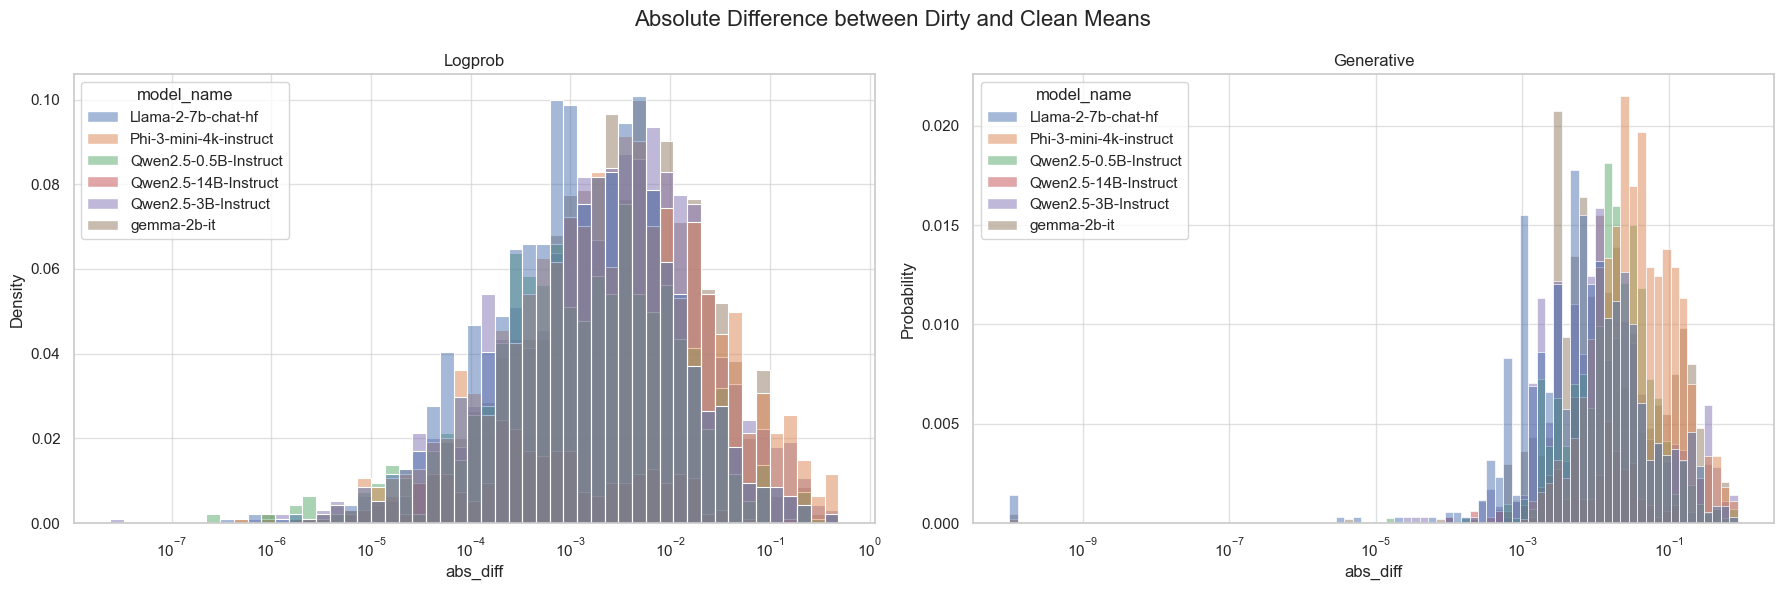

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Absolute Difference between Dirty and Clean Means", fontsize=16)

g = sns.histplot(
    logprob_results,
    x="abs_diff",
    hue="model_name",
    stat="density",
    log_scale=True,
    ax=axes[0],
)
g.set_title("Logprob")

# g = sns.histplot(
#     logprob_norm_results,
#     x="abs_diff",
#     hue="model_name",
#     stat="density",
#     log_scale=True,
#     ax=axes[1],
# )
# g.set_title("Logprob Norm")

g = sns.histplot(
    generative_results,
    x="abs_diff",
    hue="model_name",
    stat="probability",
    log_scale=True,
    ax=axes[1],
    # legend=False,
)
g.set_title("Generative")  

fig.tight_layout()
plt.show()

In [18]:
# def agg_results(
#     df: pd.DataFrame,
#     threshold: float,
#     diff_col: str = "abs_diff",
#     prob_col: str = "two_sided_tail",
#     new_col: str = "two_sided_tail_agg",
#     group_by_cols: list[str] | None = None,
#     keep_cols: list[str] = [],
# ) -> pd.DataFrame:
#     """
#     Aggregate the results into a new column (new_col) by taking the min value of the prob_col from all rows whose diff_col is above the threshold.
#     If group_by_cols is not None, group by those columns first.
#     """
#     keep_cols.append(prob_col)
#     mask = df[diff_col] >= threshold
#     if group_by_cols is not None:
#         agg_df = df[mask].groupby(group_by_cols)[keep_cols].min().reset_index()
#     else:
#         agg_df = df[mask][keep_cols].min()
#         agg_df = pd.DataFrame({new_col: [agg_df]})
#     agg_df = agg_df.rename(columns={prob_col: new_col})

#     return agg_df

def agg_results(
    df: pd.DataFrame,
    threshold: float,
    diff_col: str = "abs_diff",
    prob_col: str = "two_sided_tail",
    new_col: str = "two_sided_tail_agg",
    group_by_cols: list[str] | None = None,
    keep_cols: list[str] | None = None,
) -> pd.DataFrame:
    keep_cols_local = list(keep_cols) if keep_cols is not None else []
    keep_cols_local = list(dict.fromkeys([*keep_cols_local, prob_col]))  # unique, order-preserving

    mask = df[diff_col] >= threshold
    if group_by_cols is not None:
        agg_df = df[mask].groupby(group_by_cols)[keep_cols_local].min().reset_index()
    else:
        agg_series = df[mask][keep_cols_local].min()
        agg_df = pd.DataFrame([agg_series])

    agg_df = agg_df.rename(columns={prob_col: new_col})
    return agg_df

In [19]:
raw_keep_cols = ['global/kl_div', 'global/kl_div_max', 'global/proj_l2_rel', 'global/proj_l2_rel_max']

In [20]:
abs_diff_threshold = 0.015

agg_logprobs =  agg_results(
    logprob_results.copy(),
    threshold=abs_diff_threshold,
    diff_col="abs_diff",
    prob_col="two_sided_tail",
    new_col="two_sided_tail_agg",
    group_by_cols=["model_name", "layer_name", "kl"],
    keep_cols=raw_keep_cols,
)

# agg_logprobs_norm =  agg_results(
#     logprob_norm_results.copy(),
#     threshold=abs_diff_threshold,
#     diff_col="abs_diff",
#     prob_col="two_sided_tail",
#     new_col="two_sided_tail_agg",
#     group_by_cols=["model_name", "layer_name", "kl"],
# )

agg_generative =  agg_results(
    generative_results.copy(),
    threshold=abs_diff_threshold,
    diff_col="abs_diff",
    prob_col="two_sided_tail",
    new_col="two_sided_tail_agg",
    group_by_cols=["model_name", "layer_name", "kl"],
    keep_cols=raw_keep_cols,
)

In [21]:
agg_logprobs['choice_metric'] = agg_logprobs['global/proj_l2_rel'] * agg_logprobs['two_sided_tail_agg']
agg_generative['choice_metric'] = agg_generative['global/proj_l2_rel'] * agg_generative['two_sided_tail_agg']

In [22]:
# create ne dataframe with model_name, layer_name, kl, choice_metric for both logprobs and generative
agg_logprobs_choice = agg_logprobs[["model_name", "layer_name", "kl", "choice_metric"]]
agg_generative_choice = agg_generative[["model_name", "layer_name", "kl", "choice_metric"]]

agg_choice = agg_logprobs_choice.merge(
    agg_generative_choice,
    on=["model_name", "layer_name", "kl"],
    suffixes=("_logprob", "_generative"),
)

agg_logprobs_metrics = agg_logprobs[["model_name", "layer_name", "kl", "global/proj_l2_rel", "global/proj_l2_rel_max", "global/kl_div", "global/kl_div_max"]]

agg_choice = agg_choice.merge(
    agg_logprobs_metrics,
    on=["model_name", "layer_name", "kl"],
    how="left",
)

agg_choice

,model_name,layer_name,kl,choice_metric_logprob,choice_metric_generative,global/proj_l2_rel,global/proj_l2_rel_max,global/kl_div,global/kl_div_max
0,Llama-2-7b-chat-hf,model.embed_tokens,0.000,0.000000e+00,0.000002,0.051514,0.051514,3.044495,3.044495
1,Llama-2-7b-chat-hf,model.embed_tokens,0.125,1.232790e-03,0.000878,0.044323,0.051514,0.022527,3.044495
2,Llama-2-7b-chat-hf,model.embed_tokens,0.250,4.587264e-03,0.001640,0.043432,0.051514,0.012225,3.044495
3,Llama-2-7b-chat-hf,model.embed_tokens,0.500,1.734462e-02,0.000944,0.041279,0.051514,0.009540,3.044495
4,Llama-2-7b-chat-hf,model.layers.0,0.000,0.000000e+00,0.000009,0.454612,0.454612,6.306403,6.306403
...,...,...,...,...,...,...,...,...,...
118,gemma-2b-it,model.layers.6,1.000,3.358698e-07,0.000284,0.244198,0.299647,0.032754,1.216124
119,gemma-2b-it,model.layers.6,2.000,5.913463e-03,0.000674,0.236646,0.299647,0.021118,1.216124
120,gemma-2b-it,model.norm,0.000,0.000000e+00,0.000007,0.306153,0.306153,4.467519,4.467519
121,gemma-2b-it,model.norm,0.125,1.060813e-01,0.000834,0.292981,0.306153,0.062727,4.467519


In [23]:
# add agg_choice_metric column that is min of choice_metric_logprob and choice_metric_generative
agg_choice['agg_choice_metric'] = agg_choice[['choice_metric_logprob', 'choice_metric_generative']].min(axis=1)
agg_choice
# for each group of (model_name, layer_name) take the kl value with the highest value 

,model_name,layer_name,kl,choice_metric_logprob,choice_metric_generative,global/proj_l2_rel,global/proj_l2_rel_max,global/kl_div,global/kl_div_max,agg_choice_metric
0,Llama-2-7b-chat-hf,model.embed_tokens,0.000,0.000000e+00,0.000002,0.051514,0.051514,3.044495,3.044495,0.000000e+00
1,Llama-2-7b-chat-hf,model.embed_tokens,0.125,1.232790e-03,0.000878,0.044323,0.051514,0.022527,3.044495,8.777646e-04
2,Llama-2-7b-chat-hf,model.embed_tokens,0.250,4.587264e-03,0.001640,0.043432,0.051514,0.012225,3.044495,1.639523e-03
3,Llama-2-7b-chat-hf,model.embed_tokens,0.500,1.734462e-02,0.000944,0.041279,0.051514,0.009540,3.044495,9.436435e-04
4,Llama-2-7b-chat-hf,model.layers.0,0.000,0.000000e+00,0.000009,0.454612,0.454612,6.306403,6.306403,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
118,gemma-2b-it,model.layers.6,1.000,3.358698e-07,0.000284,0.244198,0.299647,0.032754,1.216124,3.358698e-07
119,gemma-2b-it,model.layers.6,2.000,5.913463e-03,0.000674,0.236646,0.299647,0.021118,1.216124,6.740293e-04
120,gemma-2b-it,model.norm,0.000,0.000000e+00,0.000007,0.306153,0.306153,4.467519,4.467519,0.000000e+00
121,gemma-2b-it,model.norm,0.125,1.060813e-01,0.000834,0.292981,0.306153,0.062727,4.467519,8.344864e-04


In [24]:
# Cleaner: break ties with kl first, then pick max agg_choice_metric per group via idxmax.
_tmp = agg_choice.sort_values(["model_name", "layer_name", "kl"], ascending=[True, True, False])
_idx = _tmp.groupby(["model_name", "layer_name"])["agg_choice_metric"].idxmax()

best_kl_df = (
    _tmp.loc[_idx, agg_choice.columns.tolist()]
    .sort_values(["model_name", "layer_name"])
).reset_index(drop=True)

best_kl_df

,model_name,layer_name,kl,choice_metric_logprob,choice_metric_generative,global/proj_l2_rel,global/proj_l2_rel_max,global/kl_div,global/kl_div_max,agg_choice_metric
0,Llama-2-7b-chat-hf,model.embed_tokens,0.250,4.587264e-03,0.001640,0.043432,0.051514,0.012225,3.044495,0.001640
1,Llama-2-7b-chat-hf,model.layers.0,8.000,2.551136e-02,0.033819,0.278255,0.454612,0.011568,6.306403,0.025511
2,Llama-2-7b-chat-hf,model.layers.11,2.000,2.412150e-03,0.006894,0.032334,0.090074,0.004169,1.407147,0.002412
3,Llama-2-7b-chat-hf,model.layers.21,2.000,8.557743e-03,0.032404,0.061575,0.097992,0.007845,0.795353,0.008558
4,Llama-2-7b-chat-hf,model.norm,0.000,0.000000e+00,0.001103,0.101190,0.101190,0.632451,0.632451,0.000000
5,Phi-3-mini-4k-instruct,model.embed_tokens,0.500,2.178687e-02,0.000067,0.043446,0.045035,0.005744,0.197981,0.000067
6,Phi-3-mini-4k-instruct,model.layers.0,0.500,1.840573e-03,0.002102,0.545459,0.596129,0.081633,1.521296,0.001841
7,Phi-3-mini-4k-instruct,model.layers.11,2.000,2.428329e-02,0.000688,0.355240,0.501323,0.033106,1.971606,0.000688
8,Phi-3-mini-4k-instruct,model.layers.21,1.000,1.381461e-01,0.001939,0.427598,0.492989,0.064960,1.699576,0.001939
9,Phi-3-mini-4k-instruct,model.norm,0.500,7.613699e-02,0.000529,0.502403,0.516003,0.014199,1.674800,0.000529


In [ ]:
print(best_kl_df.to_latex())

In [ ]:
def layer_order(layer_name: str) -> int:
    if ".layers." in layer_name:
        return int(layer_name.split(".")[-1])
    elif "embed_tokens" in layer_name:
        return -1
    else:
        return 1000

In [ ]:
def visualize(
        df:pd.DataFrame,
        res_name: str,
        abs_diff_threshold: float,
        row:str = None,
    ):
    g = sns.catplot(
        data=df,
        x="two_sided_tail_agg",
        y="layer_name",
        kind="bar",
        col="model_name",
        row=row,
        order=sorted(df["layer_name"].unique(), key=layer_order),
    )
    g.figure.suptitle(f"Aggregated {res_name} two-sided tail values (threshold={abs_diff_threshold})", y=1.02)

In [ ]:
visualize(agg_logprobs, "Logprob", abs_diff_threshold)
# visualize(agg_logprobs_norm, "Logprob Norm", abs_diff_threshold)
visualize(agg_generative, "Generative", abs_diff_threshold)

In [ ]:
agg_threshold = 0.15
mask_logprobs = agg_logprobs["two_sided_tail_agg"] >= agg_threshold
# mask_logprobs_norm = agg_logprobs_norm["two_sided_tail_agg"] >= agg_threshold
mask_generative = agg_generative["two_sided_tail_agg"] >= agg_threshold

visualize(agg_logprobs[mask_logprobs], f"Logprob[>{agg_threshold}]", abs_diff_threshold, row="kl")
# visualize(agg_logprobs_norm[mask_logprobs_norm], f"Logprob Norm[>{agg_threshold}]", abs_diff_threshold, row="kl")
visualize(agg_generative[mask_generative], f"Generative[>{agg_threshold}]", abs_diff_threshold, row="kl")